In [2]:
import os

os.listdir()

['.config',
 'SIMD+2020v2+-+ranks.xlsx',
 'SIMD+2020v2+-+indicators.xlsx',
 'sample_data']

In [3]:
import pandas as pd

simd_ind = pd.read_excel("SIMD+2020v2+-+indicators.xlsx")

print("Shape:", simd_ind.shape)
print("\nColumns:\n", simd_ind.columns.tolist())

simd_ind.head()

Shape: (15, 3)

Columns:
 ['Unnamed: 0', 'Unnamed: 1', 'Unnamed: 2']


,Unnamed: 0,Unnamed: 1,Unnamed: 2
0,NaN,NaN,Scottish Index of Multiple Deprivation 2020
1,NaN,NaN,NaN
2,NaN,NaN,Contents
3,NaN,NaN,Indicator descriptions:
4,NaN,NaN,Description of SIMD indicators


In [4]:
import pandas as pd

xls = pd.ExcelFile("SIMD+2020v2+-+indicators.xlsx")
print(xls.sheet_names)

['Contents & notes', 'Indicator descriptions', 'Data']


In [5]:
simd_ind = pd.read_excel("SIMD+2020v2+-+indicators.xlsx", sheet_name="Data")

print("Shape:", simd_ind.shape)
print("\nColumns:\n", simd_ind.columns.tolist())

simd_ind.head()

Shape: (6976, 37)

Columns:
 ['Data_Zone', 'Intermediate_Zone', 'Council_area', 'Total_population', 'Working_age_population', 'Income_rate', 'Income_count', 'Employment_rate', 'Employment_count', 'CIF', 'ALCOHOL', 'DRUG', 'SMR', 'DEPRESS', 'LBWT', 'EMERG', 'Attendance', 'Attainment', 'no_qualifications', 'not_participating', 'University', 'drive_petrol', 'drive_GP', 'drive_post', 'drive_primary', 'drive_retail', 'drive_secondary', 'PT_GP', 'PT_post', 'PT_retail', 'Broadband', 'crime_count', 'crime_rate', 'overcrowded_count', 'nocentralheat_count', 'overcrowded_rate', 'nocentralheat_rate']


,Data_Zone,Intermediate_Zone,Council_area,Total_population,Working_age_population,Income_rate,Income_count,Employment_rate,Employment_count,CIF,...,PT_GP,PT_post,PT_retail,Broadband,crime_count,crime_rate,overcrowded_count,nocentralheat_count,overcrowded_rate,nocentralheat_rate
0,S01006506,Culter,Aberdeen City,894,580,0.08,71,0.08,49,65,...,8.863589,5.856135,6.023406,0.105051,11.139188,124.59942,87,10,0.102113,0.011737
1,S01006507,Culter,Aberdeen City,793,470,0.05,43,0.05,25,45,...,9.978272,7.515000,7.926029,0.013587,10.126535,127.69905,85,4,0.101675,0.004785
2,S01006508,Culter,Aberdeen City,624,461,0.06,40,0.04,19,45,...,8.620700,4.321493,5.770910,0.005634,8.101228,129.827368,31,8,0.048212,0.012442
3,S01006509,Culter,Aberdeen City,537,307,0.1,52,0.08,26,80,...,7.935112,8.433328,8.329819,0.113074,4.050614,75.430426,42,6,0.072414,0.010345
4,S01006510,Culter,Aberdeen City,663,415,0.1,68,0.08,32,95,...,5.568964,6.966429,6.632609,0.003096,11.139188,168.011888,50,7,0.086655,0.012132


In [6]:
# Filter to Inverclyde
simd_inv = simd_ind[simd_ind["Council_area"] == "Inverclyde"].copy()

print("Shape after filtering:", simd_inv.shape)
simd_inv.head()

Shape after filtering: (114, 37)


,Data_Zone,Intermediate_Zone,Council_area,Total_population,Working_age_population,Income_rate,Income_count,Employment_rate,Employment_count,CIF,...,PT_GP,PT_post,PT_retail,Broadband,crime_count,crime_rate,overcrowded_count,nocentralheat_count,overcrowded_rate,nocentralheat_rate
4310,S01010816,Kilmacolm Central,Inverclyde,655,340,0.04,26,0.02,7,60,...,3.301727,3.609874,3.443241,0.22082,*,*,37,1,0.058360,0.001577
4311,S01010817,Kilmacolm Central,Inverclyde,928,509,0.04,36,0.03,17,45,...,10.368840,11.608840,11.918840,0.012887,7.038026,75.8408,44,6,0.048619,0.006630
4312,S01010818,Kilmacolm Central,Inverclyde,998,555,0.05,52,0.04,20,50,...,5.669837,5.076889,5.565128,0.223092,6.032594,60.446833,74,13,0.072978,0.012821
4313,S01010819,"Kilmacolm, Quarriers, Greenock Upper East/Central",Inverclyde,761,459,0.1,75,0.07,32,95,...,8.042550,8.015590,7.822714,0.209302,10.054323,132.119885,77,14,0.095652,0.017391
4314,S01010820,"Kilmacolm, Quarriers, Greenock Upper East/Central",Inverclyde,537,321,0.07,36,0.08,26,75,...,13.317954,14.005833,14.299518,0.310345,7.038026,131.061941,19,11,0.036122,0.020913


In [7]:
# Check data types
print(simd_inv.dtypes)

# Check missing values
print("\nMissing values per column:\n")
print(simd_inv.isna().sum())

# Check for non-numeric entries like "*"
for col in simd_inv.columns:
    if simd_inv[col].dtype == "object":
        unique_vals = simd_inv[col].unique()
        if "*" in unique_vals:
            print(f"Column with '*': {col}")

Data_Zone                  object
Intermediate_Zone          object
Council_area               object
Total_population            int64
Working_age_population      int64
Income_rate                object
Income_count                int64
Employment_rate            object
Employment_count            int64
CIF                        object
ALCOHOL                    object
DRUG                       object
SMR                        object
DEPRESS                    object
LBWT                       object
EMERG                      object
Attendance                 object
Attainment                 object
no_qualifications         float64
not_participating          object
University                 object
drive_petrol              float64
drive_GP                  float64
drive_post                float64
drive_primary             float64
drive_retail              float64
drive_secondary           float64
PT_GP                     float64
PT_post                   float64
PT_retail     

In [8]:
import numpy as np

# Select relevant columns for modelling
cols_to_use = [
    "Data_Zone",
    "Total_population",
    "Working_age_population",
    "Income_rate",
    "Employment_rate",
    "no_qualifications",
    "University",
    "crime_rate",
    "overcrowded_rate",
    "nocentralheat_rate",
    "Broadband",
    "drive_retail",
    "drive_GP",
    "PT_retail",
    "PT_GP"
]

simd_model = simd_inv[cols_to_use].copy()

# Replace '*' with NaN
simd_model.replace("*", np.nan, inplace=True)

# Convert to numeric where possible
for col in simd_model.columns:
    if col != "Data_Zone":
        simd_model[col] = pd.to_numeric(simd_model[col], errors="coerce")

# Check missing after conversion
print("Missing values after cleaning:\n")
print(simd_model.isna().sum())

print("\nFinal shape:", simd_model.shape)

simd_model.head()

Missing values after cleaning:

Data_Zone                  0
Total_population           0
Working_age_population     0
Income_rate                0
Employment_rate            0
no_qualifications          0
University                 0
crime_rate                11
overcrowded_rate           0
nocentralheat_rate         0
Broadband                  0
drive_retail               0
drive_GP                   0
PT_retail                  0
PT_GP                      0
dtype: int64

Final shape: (114, 15)


/tmp/ipython-input-1985/2182715019.py:25: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  simd_model.replace("*", np.nan, inplace=True)


,Data_Zone,Total_population,Working_age_population,Income_rate,Employment_rate,no_qualifications,University,crime_rate,overcrowded_rate,nocentralheat_rate,Broadband,drive_retail,drive_GP,PT_retail,PT_GP
4310,S01010816,655,340,0.04,0.02,31.734209,0.217742,NaN,0.058360,0.001577,0.220820,1.225635,1.062812,3.443241,3.301727
4311,S01010817,928,509,0.04,0.03,39.107852,0.286713,75.840800,0.048619,0.006630,0.012887,2.787854,2.426409,11.918840,10.368840
4312,S01010818,998,555,0.05,0.04,36.187461,0.364486,60.446833,0.072978,0.012821,0.223092,1.360821,1.389776,5.565128,5.669837
4313,S01010819,761,459,0.10,0.07,71.335773,0.114035,132.119885,0.095652,0.017391,0.209302,2.133183,2.168528,7.822714,8.042550
4314,S01010820,537,321,0.07,0.08,38.922526,0.213333,131.061941,0.036122,0.020913,0.310345,4.437295,4.214511,14.299518,13.317954


In [9]:
# Impute crime_rate with median
median_crime = simd_model["crime_rate"].median()
simd_model["crime_rate"].fillna(median_crime, inplace=True)

# Confirm no missing values remain
print("Missing after imputation:\n")
print(simd_model.isna().sum())

Missing after imputation:

Data_Zone                 0
Total_population          0
Working_age_population    0
Income_rate               0
Employment_rate           0
no_qualifications         0
University                0
crime_rate                0
overcrowded_rate          0
nocentralheat_rate        0
Broadband                 0
drive_retail              0
drive_GP                  0
PT_retail                 0
PT_GP                     0
dtype: int64


/tmp/ipython-input-1985/800750986.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  simd_model["crime_rate"].fillna(median_crime, inplace=True)


In [10]:
simd_model.describe()

,Total_population,Working_age_population,Income_rate,Employment_rate,no_qualifications,University,crime_rate,overcrowded_rate,nocentralheat_rate,Broadband,drive_retail,drive_GP,PT_retail,PT_GP
count,114.000000,114.000000,114.000000,114.000000,114.000000,114.000000,114.000000,114.000000,114.000000,114.000000,114.000000,114.000000,114.000000,114.000000
mean,690.877193,436.631579,0.183509,0.150088,125.198138,0.080617,324.335544,0.139758,0.015544,0.028488,4.904196,3.202798,13.011923,9.515755
std,155.671093,106.370721,0.124410,0.099410,59.134220,0.060443,392.939350,0.064491,0.016795,0.067499,2.934104,1.564946,6.532327,4.336074
min,361.000000,238.000000,0.010000,0.010000,31.404033,0.000000,34.910845,0.002817,0.000000,0.000000,0.948045,0.891865,3.443241,2.706650
25%,577.500000,356.250000,0.072500,0.062500,68.660984,0.037796,142.009074,0.088021,0.004872,0.000000,3.047261,2.006123,8.407727,6.162608
50%,684.500000,424.000000,0.165000,0.150000,129.958953,0.061553,233.821470,0.152187,0.009659,0.000000,4.272654,2.951444,11.525165,8.991588
75%,785.500000,504.750000,0.280000,0.217500,183.168520,0.109638,354.249360,0.188080,0.020387,0.006642,5.715500,4.112682,16.576003,11.965020
max,1172.000000,813.000000,0.490000,0.440000,236.412517,0.364486,3404.042167,0.280523,0.114583,0.310345,15.131989,7.517957,39.625649,24.463343


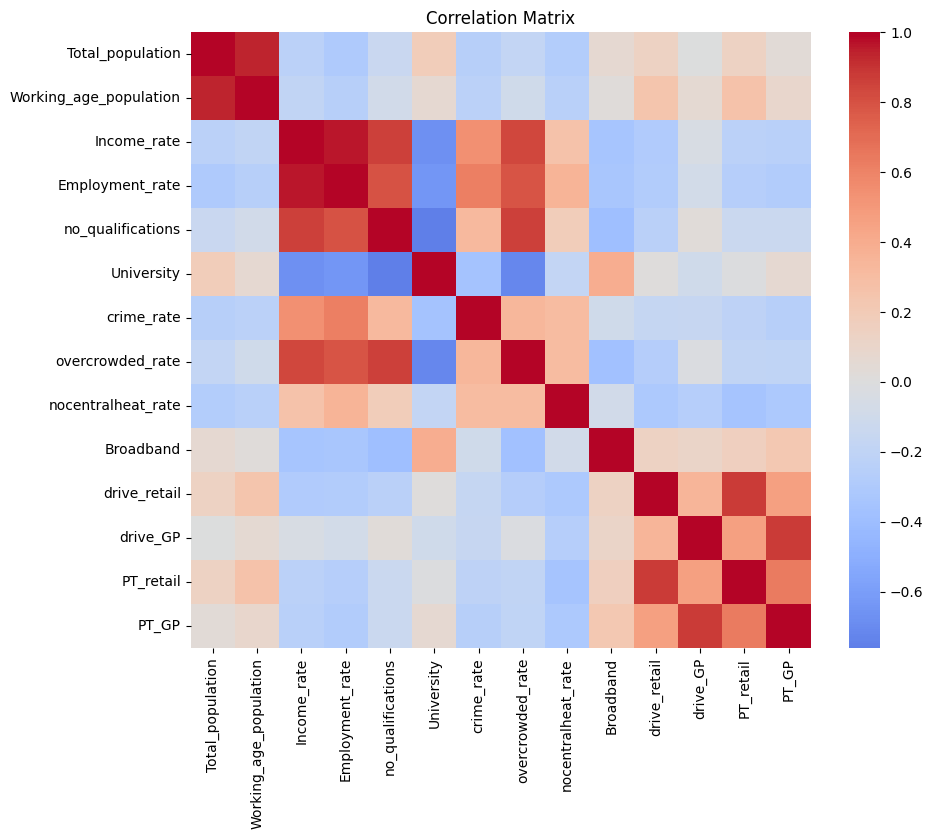

,Total_population,Working_age_population,Income_rate,Employment_rate,no_qualifications,University,crime_rate,overcrowded_rate,nocentralheat_rate,Broadband,drive_retail,drive_GP,PT_retail,PT_GP
Total_population,1.00,0.94,-0.23,-0.30,-0.15,0.18,-0.26,-0.18,-0.28,0.07,0.14,-0.00,0.13,0.03
Working_age_population,0.94,1.00,-0.19,-0.25,-0.09,0.06,-0.23,-0.10,-0.24,0.02,0.24,0.06,0.26,0.09
Income_rate,-0.23,-0.19,1.00,0.96,0.86,-0.67,0.54,0.84,0.26,-0.35,-0.29,-0.04,-0.23,-0.24
Employment_rate,-0.30,-0.25,0.96,1.00,0.80,-0.64,0.62,0.79,0.35,-0.34,-0.28,-0.08,-0.26,-0.29
no_qualifications,-0.15,-0.09,0.86,0.80,1.00,-0.76,0.32,0.86,0.18,-0.39,-0.24,0.02,-0.13,-0.14
University,0.18,0.06,-0.67,-0.64,-0.76,1.00,-0.36,-0.71,-0.18,0.39,0.01,-0.10,-0.01,0.07
crime_rate,-0.26,-0.23,0.54,0.62,0.32,-0.36,1.00,0.34,0.31,-0.09,-0.17,-0.16,-0.22,-0.26
overcrowded_rate,-0.18,-0.10,0.84,0.79,0.86,-0.71,0.34,1.00,0.31,-0.38,-0.27,-0.02,-0.18,-0.19
nocentralheat_rate,-0.28,-0.24,0.26,0.35,0.18,-0.18,0.31,0.31,1.00,-0.09,-0.31,-0.27,-0.35,-0.31
Broadband,0.07,0.02,-0.35,-0.34,-0.39,0.39,-0.09,-0.38,-0.09,1.00,0.14,0.12,0.15,0.22


In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

# Drop Data_Zone for correlation
corr = simd_model.drop(columns=["Data_Zone"]).corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Matrix")
plt.show()

corr.round(2)

In [12]:
cols_final = [
    "Data_Zone",
    "Total_population",
    "Income_rate",
    "no_qualifications",
    "University",
    "crime_rate",
    "overcrowded_rate",
    "nocentralheat_rate",
    "Broadband",
    "drive_retail",
    "drive_GP"
]

simd_final = simd_model[cols_final].copy()

print("Final modelling shape:", simd_final.shape)
simd_final.head()

Final modelling shape: (114, 11)


,Data_Zone,Total_population,Income_rate,no_qualifications,University,crime_rate,overcrowded_rate,nocentralheat_rate,Broadband,drive_retail,drive_GP
4310,S01010816,655,0.04,31.734209,0.217742,233.821470,0.058360,0.001577,0.220820,1.225635,1.062812
4311,S01010817,928,0.04,39.107852,0.286713,75.840800,0.048619,0.006630,0.012887,2.787854,2.426409
4312,S01010818,998,0.05,36.187461,0.364486,60.446833,0.072978,0.012821,0.223092,1.360821,1.389776
4313,S01010819,761,0.10,71.335773,0.114035,132.119885,0.095652,0.017391,0.209302,2.133183,2.168528
4314,S01010820,537,0.07,38.922526,0.213333,131.061941,0.036122,0.020913,0.310345,4.437295,4.214511


In [13]:
import numpy as np

np.random.seed(42)

# Standardize predictors for controlled influence
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_std = scaler.fit_transform(simd_final.drop(columns=["Data_Zone"]))

X_std = pd.DataFrame(X_std, columns=simd_final.columns[1:])

# Construct linear participation score
linear_score = (
    -1.0 * X_std["Income_rate"]
    -0.8 * X_std["no_qualifications"]
    +0.8 * X_std["University"]
    -0.5 * X_std["overcrowded_rate"]
    -0.4 * X_std["crime_rate"]
    -0.2 * X_std["nocentralheat_rate"]
    +0.3 * X_std["Broadband"]
    -0.2 * X_std["drive_retail"]
    -0.2 * X_std["drive_GP"]
)

# Convert to probability via logistic function
participation_prob = 1 / (1 + np.exp(-linear_score))

# Generate binary participation outcome
participation = np.random.binomial(1, participation_prob)

simd_final["participation"] = participation
simd_final["participation_prob"] = participation_prob

# Check distribution
print(simd_final["participation"].value_counts())
print("\nMean participation rate:", simd_final["participation"].mean())

participation
1    59
0    55
Name: count, dtype: int64

Mean participation rate: 0.5175438596491229


In [14]:
# Define X and y
X = simd_final.drop(columns=["Data_Zone", "participation", "participation_prob"])
y = simd_final["participation"]

print("X shape:", X.shape)
print("y distribution:\n", y.value_counts())

X shape: (114, 10)
y distribution:
 participation
1    59
0    55
Name: count, dtype: int64


In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    stratify=y,
    random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("\nTrain class distribution:\n", y_train.value_counts())
print("\nTest class distribution:\n", y_test.value_counts())

Train shape: (79, 10)
Test shape: (35, 10)

Train class distribution:
 participation
1    41
0    38
Name: count, dtype: int64

Test class distribution:
 participation
1    18
0    17
Name: count, dtype: int64


In [16]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Logistic regression
lr = LogisticRegression()
lr.fit(X_train_scaled, y_train)

# Predictions
y_pred_lr = lr.predict(X_test_scaled)
y_proba_lr = lr.predict_proba(X_test_scaled)[:, 1]

# Evaluation
print("ROC-AUC:", roc_auc_score(y_test, y_proba_lr))
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))

ROC-AUC: 0.9183006535947712

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.88      0.86        17
           1       0.88      0.83      0.86        18

    accuracy                           0.86        35
   macro avg       0.86      0.86      0.86        35
weighted avg       0.86      0.86      0.86        35


Confusion Matrix:
 [[15  2]
 [ 3 15]]


In [17]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

print("Random Forest ROC-AUC:", roc_auc_score(y_test, y_proba_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

Random Forest ROC-AUC: 0.9411764705882352

Classification Report:
               precision    recall  f1-score   support

           0       0.81      1.00      0.89        17
           1       1.00      0.78      0.88        18

    accuracy                           0.89        35
   macro avg       0.90      0.89      0.88        35
weighted avg       0.91      0.89      0.88        35


Confusion Matrix:
 [[17  0]
 [ 4 14]]


In [18]:
import lightgbm as lgb

lgb_model = lgb.LGBMClassifier(
    n_estimators=300,
    random_state=42
)

lgb_model.fit(X_train, y_train)

y_pred_lgb = lgb_model.predict(X_test)
y_proba_lgb = lgb_model.predict_proba(X_test)[:, 1]

print("LightGBM ROC-AUC:", roc_auc_score(y_test, y_proba_lgb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_lgb))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_lgb))

[LightGBM] [Info] Number of positive: 41, number of negative: 38
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000145 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 250
[LightGBM] [Info] Number of data points in the train set: 79, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.518987 -> initscore=0.075986
[LightGBM] [Info] Start training from score 0.075986
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain

              Feature  Importance
9            drive_GP         131
8        drive_retail         102
5    overcrowded_rate          95
0    Total_population          86
1         Income_rate          60
6  nocentralheat_rate          44
3          University          41
4          crime_rate          36
2   no_qualifications          26
7           Broadband           1


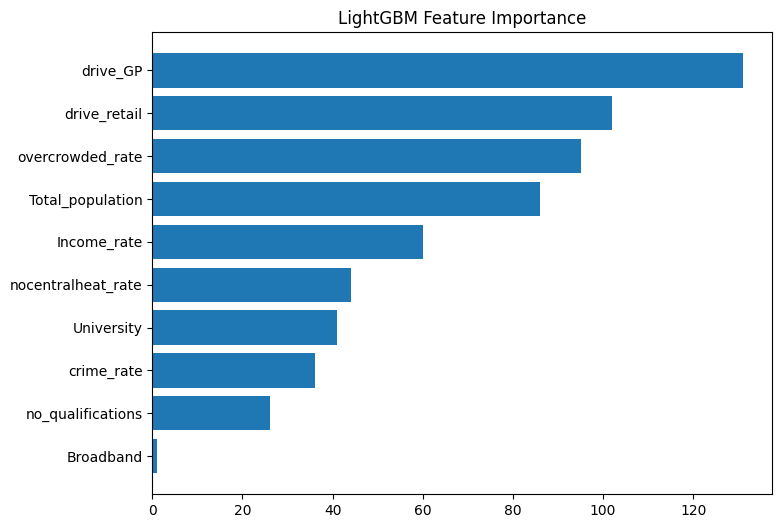

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": lgb_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print(feature_importance)

plt.figure(figsize=(8,6))
plt.barh(feature_importance["Feature"], feature_importance["Importance"])
plt.gca().invert_yaxis()
plt.title("LightGBM Feature Importance")
plt.show()

In [1]:
# Recreate explainer
explainer = shap.TreeExplainer(lgb_model)

# Get SHAP values correctly
shap_values = explainer(X_test)

# Summary plot
shap.summary_plot(shap_values.values, X_test)

NameError: name 'shap' is not defined

In [22]:
import numpy as np

# Use LightGBM probabilities
probs = y_proba_lgb

# Sort by predicted probability (ascending = lowest participation)
sorted_indices = np.argsort(probs)

# Select bottom 20% (highest predicted non-participation risk)
k = int(0.2 * len(probs))
target_indices = sorted_indices[:k]

# Calculate recall for non-participation class (0)
true_non_participants = (y_test == 0).sum()
correctly_identified = (y_test.iloc[target_indices] == 0).sum()

recall_top20 = correctly_identified / true_non_participants

print("Top 20% targeting size:", k)
print("True non-participating in test set:", true_non_participants)
print("Correctly identified in top 20%:", correctly_identified)
print("Recall@Top20% (non-participation):", recall_top20)

Top 20% targeting size: 7
True non-participating in test set: 17
Correctly identified in top 20%: 7
Recall@Top20% (non-participation): 0.4117647058823529


In [23]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

lgb_cv = lgb.LGBMClassifier(n_estimators=300, random_state=42)

cv_auc = cross_val_score(
    lgb_cv,
    X,
    y,
    cv=cv,
    scoring="roc_auc"
)

print("Cross-Validation ROC-AUC scores:", cv_auc)
print("Mean CV ROC-AUC:", cv_auc.mean())
print("Std Dev CV ROC-AUC:", cv_auc.std())

[LightGBM] [Info] Number of positive: 47, number of negative: 44
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000050 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 284
[LightGBM] [Info] Number of data points in the train set: 91, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.516484 -> initscore=0.065958
[LightGBM] [Info] Start training from score 0.065958
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain

In [24]:
import numpy as np
from sklearn.metrics import roc_auc_score

# Create income median split
median_income = X_test["Income_rate"].median()

low_income_idx = X_test["Income_rate"] <= median_income
high_income_idx = X_test["Income_rate"] > median_income

# Predicted probabilities
y_probs = lgb_model.predict_proba(X_test)[:,1]

# Compute group AUCs
auc_low = roc_auc_score(y_test[low_income_idx], y_probs[low_income_idx])
auc_high = roc_auc_score(y_test[high_income_idx], y_probs[high_income_idx])

print("Low income AUC:", auc_low)
print("High income AUC:", auc_high)

Low income AUC: 0.9375
High income AUC: 0.7857142857142857


In [28]:
# Get LightGBM predicted participation probabilities for full dataset
full_probs = lgb_model.predict_proba(X)[:, 1]

# Contamination probability = inverse participation probability
contamination_prob = 1 - full_probs

# Generate contamination outcome
np.random.seed(42)
contamination = np.random.binomial(1, contamination_prob)

simd_final["contamination"] = contamination
simd_final["contamination_prob"] = contamination_prob

print(simd_final["contamination"].value_counts())
print("Mean contamination rate:", simd_final["contamination"].mean())

contamination
1    58
0    56
Name: count, dtype: int64
Mean contamination rate: 0.5087719298245614


In [29]:
# Define target
y_cont = simd_final["contamination"]

# Train-test split (same structure for fairness)
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X, y_cont,
    test_size=0.3,
    stratify=y_cont,
    random_state=42
)

# Train LightGBM
lgb_cont = lgb.LGBMClassifier(n_estimators=300, random_state=42)
lgb_cont.fit(X_train_c, y_train_c)

# Predictions
y_pred_cont = lgb_cont.predict(X_test_c)
y_proba_cont = lgb_cont.predict_proba(X_test_c)[:,1]

# Evaluation
print("Contamination ROC-AUC:", roc_auc_score(y_test_c, y_proba_cont))
print("\nClassification Report:\n", classification_report(y_test_c, y_pred_cont))
print("\nConfusion Matrix:\n", confusion_matrix(y_test_c, y_pred_cont))

[LightGBM] [Info] Number of positive: 40, number of negative: 39
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000053 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 250
[LightGBM] [Info] Number of data points in the train set: 79, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.506329 -> initscore=0.025318
[LightGBM] [Info] Start training from score 0.025318
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain

In [30]:
from sklearn.metrics import accuracy_score, recall_score, precision_score

thresholds = [0.4, 0.5, 0.6]

print("Threshold Sensitivity Analysis\n")

for t in thresholds:
    y_pred_thresh = (y_proba_lgb >= t).astype(int)

    acc = accuracy_score(y_test, y_pred_thresh)
    recall = recall_score(y_test, y_pred_thresh)
    precision = precision_score(y_test, y_pred_thresh)

    print(f"Threshold: {t}")
    print(f"Accuracy: {acc:.3f}")
    print(f"Recall (Participation=1): {recall:.3f}")
    print(f"Precision (Participation=1): {precision:.3f}")
    print("-" * 30)

Threshold Sensitivity Analysis

Threshold: 0.4
Accuracy: 0.914
Recall (Participation=1): 0.833
Precision (Participation=1): 1.000
------------------------------
Threshold: 0.5
Accuracy: 0.914
Recall (Participation=1): 0.833
Precision (Participation=1): 1.000
------------------------------
Threshold: 0.6
Accuracy: 0.914
Recall (Participation=1): 0.833
Precision (Participation=1): 1.000
------------------------------
